In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.glm.first_level import make_first_level_design_matrix
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SUBJECT_ID = "100206"

RAW_RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
)

SYNTHETIC_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
)

NOISY_DATA_DIR = (
    SYNTHETIC_DATA_DIR
    / "noisy"
)

GROUND_TRUTH_HRF_PATH = (
    SYNTHETIC_DATA_DIR
    / "ground_truth_hrf.csv"
)

NOISE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "noise_dataset_summary.csv"
)

GLM_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "glm"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

GLM_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Resumen de ruido:", NOISE_SUMMARY_PATH.exists())
print("HRF verdadera:", GROUND_TRUTH_HRF_PATH.exists())

Resumen de ruido: True
HRF verdadera: True


In [5]:
noise_summary = pd.read_csv(
    NOISE_SUMMARY_PATH
)

ground_truth_hrf = pd.read_csv(
    GROUND_TRUTH_HRF_PATH
)

print(
    "Señales disponibles:",
    len(noise_summary),
)

print(
    "Escenarios:",
    noise_summary["scenario"].nunique(),
)

print(
    "Niveles SNR:",
    sorted(
        noise_summary["target_snr"].unique()
    ),
)

display(
    noise_summary.head()
)

Señales disponibles: 60
Escenarios: 4
Niveles SNR: [np.float64(2.0), np.float64(5.0), np.float64(10.0)]


,scenario,run,roi,condition,snr_name,target_snr,realized_snr,replicate,random_seed,clean_std_fraction,noise_std_fraction,n_train_points,n_test_points,test_start_s,test_end_s,held_out_onset_s,output_file
0,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,1,20260718,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
1,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,2,20260719,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
2,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,3,20260720,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
3,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,4,20260721,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
4,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,5,20260722,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...


In [6]:
SCENARIO_CONFIG = {
    "motor_lr_m1_left": {
        "run": "MOTOR_LR",
        "roi": "M1_left",
        "condition": "rh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
            / "EVs"
        ),
    },
    "motor_lr_m1_right": {
        "run": "MOTOR_LR",
        "roi": "M1_right",
        "condition": "lh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
            / "EVs"
        ),
    },
    "motor_rl_m1_left": {
        "run": "MOTOR_RL",
        "roi": "M1_left",
        "condition": "rh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
            / "EVs"
        ),
    },
    "motor_rl_m1_right": {
        "run": "MOTOR_RL",
        "roi": "M1_right",
        "condition": "lh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
            / "EVs"
        ),
    },
}

In [7]:
def cargar_eventos_glm(
    events_dir: Path,
    condition: str,
) -> pd.DataFrame:
    """
    Lee los eventos de la condición contralateral y los
    convierte al formato utilizado por Nilearn.
    """
    event_path = (
        events_dir
        / f"{condition}.txt"
    )

    if not event_path.exists():
        raise FileNotFoundError(
            f"No se encontró: {event_path}"
        )

    values = np.loadtxt(
        event_path,
        ndmin=2,
    )

    if values.shape[1] < 3:
        raise ValueError(
            f"{event_path.name} no contiene tres columnas."
        )

    events = pd.DataFrame(
        {
            "onset": values[:, 0],
            "duration": values[:, 1],
            "trial_type": "stimulus",
        }
    )

    return events

In [8]:
def construir_diseño_glm(
    frame_times: np.ndarray,
    events: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye un GLM con HRF canónica SPM, deriva
    temporal cosenoidal y constante.
    """
    frame_times = np.asarray(
        frame_times,
        dtype=float,
    )

    design_matrix = (
        make_first_level_design_matrix(
            frame_times=frame_times,
            events=events,
            hrf_model="spm",
            drift_model="cosine",
            high_pass=0.008,
            min_onset=-24,
        )
    )

    if "stimulus" not in design_matrix.columns:
        raise RuntimeError(
            "No se generó el regresor del estímulo."
        )

    return design_matrix

In [9]:
def correlacion_segura(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> float:
    """
    Calcula correlación de Pearson evitando errores
    cuando una señal es prácticamente constante.
    """
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    if (
        np.std(observed) < 1e-12
        or np.std(predicted) < 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            observed,
            predicted,
        )[0, 1]
    )

In [10]:
def calcular_metricas(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    """
    Calcula métricas entre una señal verdadera y una
    predicción.
    """
    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    mse = mean_squared_error(
        observed,
        predicted,
    )

    return {
        "mse_fraction": float(mse),
        "rmse_fraction": float(
            np.sqrt(mse)
        ),
        "rmse_percent": float(
            100.0 * np.sqrt(mse)
        ),
        "mae_fraction": float(
            mean_absolute_error(
                observed,
                predicted,
            )
        ),
        "mae_percent": float(
            100.0
            * mean_absolute_error(
                observed,
                predicted,
            )
        ),
        "r2": float(
            r2_score(
                observed,
                predicted,
            )
        ),
        "pearson_r": (
            correlacion_segura(
                observed,
                predicted,
            )
        ),
    }

In [11]:
def ajustar_glm_sintetico(
    design_matrix: pd.DataFrame,
    noisy_signal: np.ndarray,
    train_mask: np.ndarray,
) -> dict:
    """
    Estima el GLM en los puntos de entrenamiento y
    genera una predicción para toda la serie.
    """
    X = design_matrix.to_numpy(
        dtype=float,
    )

    y = np.asarray(
        noisy_signal,
        dtype=float,
    ).reshape(-1)

    train_mask = np.asarray(
        train_mask,
        dtype=bool,
    )

    if len(y) != X.shape[0]:
        raise ValueError(
            "La señal y la matriz de diseño "
            "tienen distintas longitudes."
        )

    if len(train_mask) != len(y):
        raise ValueError(
            "La máscara no coincide con la señal."
        )

    X_train = X[train_mask]
    y_train = y[train_mask]

    beta, _, rank, singular_values = (
        np.linalg.lstsq(
            X_train,
            y_train,
            rcond=None,
        )
    )

    prediction = X @ beta

    coefficients = pd.Series(
        beta,
        index=design_matrix.columns,
        name="beta",
    )

    return {
        "prediction": prediction,
        "coefficients": coefficients,
        "rank": int(rank),
        "singular_values": singular_values,
    }

In [12]:
hrf_reference = ground_truth_hrf.loc[
    ground_truth_hrf[
        "time_from_onset_s"
    ] >= 0.0
].copy()

HRF_EVALUATION_TIMES = (
    hrf_reference[
        "time_from_onset_s"
    ].to_numpy(dtype=float)
)

HRF_TRUE = (
    hrf_reference[
        "bold_fraction"
    ].to_numpy(dtype=float)
)

In [13]:
def generar_hrf_glm(
    beta_stimulus: float,
    evaluation_times: np.ndarray,
) -> np.ndarray:
    """
    Genera la respuesta del GLM a un evento de 1 s
    usando la HRF canónica SPM.
    """
    event = pd.DataFrame(
        {
            "onset": [0.0],
            "duration": [1.0],
            "trial_type": ["stimulus"],
        }
    )

    design = make_first_level_design_matrix(
        frame_times=evaluation_times,
        events=event,
        hrf_model="spm",
        drift_model=None,
        min_onset=-24,
    )

    canonical_response = (
        design["stimulus"]
        .to_numpy(dtype=float)
    )

    return (
        float(beta_stimulus)
        * canonical_response
    )

In [14]:
def calcular_metricas_hrf(
    true_hrf: np.ndarray,
    estimated_hrf: np.ndarray,
    time_s: np.ndarray,
) -> dict:
    """
    Evalúa error de forma, amplitud y tiempo al pico.
    """
    true_hrf = np.asarray(
        true_hrf,
        dtype=float,
    )

    estimated_hrf = np.asarray(
        estimated_hrf,
        dtype=float,
    )

    time_s = np.asarray(
        time_s,
        dtype=float,
    )

    metrics = calcular_metricas(
        true_hrf,
        estimated_hrf,
    )

    true_peak_index = int(
        np.argmax(true_hrf)
    )

    estimated_peak_index = int(
        np.argmax(estimated_hrf)
    )

    true_peak_amplitude = float(
        true_hrf[true_peak_index]
    )

    estimated_peak_amplitude = float(
        estimated_hrf[
            estimated_peak_index
        ]
    )

    true_peak_time = float(
        time_s[true_peak_index]
    )

    estimated_peak_time = float(
        time_s[estimated_peak_index]
    )

    metrics.update(
        {
            "true_peak_percent": (
                100.0
                * true_peak_amplitude
            ),
            "estimated_peak_percent": (
                100.0
                * estimated_peak_amplitude
            ),
            "peak_amplitude_error_percent": (
                100.0
                * (
                    estimated_peak_amplitude
                    - true_peak_amplitude
                )
            ),
            "true_time_to_peak_s": (
                true_peak_time
            ),
            "estimated_time_to_peak_s": (
                estimated_peak_time
            ),
            "time_to_peak_error_s": (
                estimated_peak_time
                - true_peak_time
            ),
        }
    )

    return metrics

In [15]:
design_cache = {}
events_cache = {}

for scenario_name, config in (
    SCENARIO_CONFIG.items()
):
    events = cargar_eventos_glm(
        config["events_dir"],
        config["condition"],
    )

    events_cache[scenario_name] = events

    example_path = (
        NOISY_DATA_DIR
        / scenario_name
        / "snr_10"
        / (
            f"{scenario_name}_"
            f"snr_10_rep_01.csv"
        )
    )

    example_table = pd.read_csv(
        example_path
    )

    frame_times = (
        example_table["time_s"]
        .to_numpy(dtype=float)
    )

    design_cache[scenario_name] = (
        construir_diseño_glm(
            frame_times,
            events,
        )
    )

    print(
        scenario_name,
        design_cache[
            scenario_name
        ].shape,
        list(
            design_cache[
                scenario_name
            ].columns
        ),
    )

motor_lr_m1_left (284, 5) ['stimulus', 'drift_1', 'drift_2', 'drift_3', 'constant']
motor_lr_m1_right (284, 5) ['stimulus', 'drift_1', 'drift_2', 'drift_3', 'constant']
motor_rl_m1_left (284, 5) ['stimulus', 'drift_1', 'drift_2', 'drift_3', 'constant']
motor_rl_m1_right (284, 5) ['stimulus', 'drift_1', 'drift_2', 'drift_3', 'constant']


In [16]:
metrics_rows = []
prediction_tables = []
hrf_tables = []

for _, experiment in (
    noise_summary.iterrows()
):
    scenario_name = experiment[
        "scenario"
    ]

    snr_name = experiment[
        "snr_name"
    ]

    replicate = int(
        experiment["replicate"]
    )

    file_name = (
        f"{scenario_name}_"
        f"{snr_name}_"
        f"rep_{replicate:02d}.csv"
    )

    noisy_path = (
        NOISY_DATA_DIR
        / scenario_name
        / snr_name
        / file_name
    )

    if not noisy_path.exists():
        raise FileNotFoundError(
            noisy_path
        )

    table = pd.read_csv(
        noisy_path
    )

    design_matrix = (
        design_cache[
            scenario_name
        ]
    )

    train_mask = (
        table["train_mask"]
        .to_numpy(dtype=bool)
    )

    test_mask = (
        table["test_mask"]
        .to_numpy(dtype=bool)
    )

    noisy_signal = (
        table[
            "bold_noisy_fraction"
        ].to_numpy(dtype=float)
    )

    clean_signal = (
        table[
            "bold_clean_fraction"
        ].to_numpy(dtype=float)
    )

    glm_result = ajustar_glm_sintetico(
        design_matrix=design_matrix,
        noisy_signal=noisy_signal,
        train_mask=train_mask,
    )

    full_prediction = glm_result[
        "prediction"
    ]

    # Evaluación primaria contra la señal limpia
    test_metrics = calcular_metricas(
        clean_signal[test_mask],
        full_prediction[test_mask],
    )

    # Control del ajuste sobre entrenamiento ruidoso
    train_metrics = calcular_metricas(
        noisy_signal[train_mask],
        full_prediction[train_mask],
    )

    beta_stimulus = float(
        glm_result[
            "coefficients"
        ]["stimulus"]
    )

    estimated_hrf = generar_hrf_glm(
        beta_stimulus=beta_stimulus,
        evaluation_times=(
            HRF_EVALUATION_TIMES
        ),
    )

    hrf_metrics = calcular_metricas_hrf(
        true_hrf=HRF_TRUE,
        estimated_hrf=estimated_hrf,
        time_s=HRF_EVALUATION_TIMES,
    )

    metrics_rows.append(
        {
            "scenario": scenario_name,
            "run": experiment["run"],
            "roi": experiment["roi"],
            "condition": experiment[
                "condition"
            ],
            "snr_name": snr_name,
            "target_snr": float(
                experiment["target_snr"]
            ),
            "replicate": replicate,
            "random_seed": int(
                experiment["random_seed"]
            ),
            "beta_stimulus_fraction": (
                beta_stimulus
            ),
            "beta_stimulus_percent": (
                100.0
                * beta_stimulus
            ),
            "n_train_points": int(
                np.sum(train_mask)
            ),
            "n_test_points": int(
                np.sum(test_mask)
            ),
            "test_rmse_percent": (
                test_metrics[
                    "rmse_percent"
                ]
            ),
            "test_mae_percent": (
                test_metrics[
                    "mae_percent"
                ]
            ),
            "test_r2": (
                test_metrics["r2"]
            ),
            "test_pearson_r": (
                test_metrics[
                    "pearson_r"
                ]
            ),
            "train_rmse_percent": (
                train_metrics[
                    "rmse_percent"
                ]
            ),
            "train_r2": (
                train_metrics["r2"]
            ),
            "hrf_rmse_percent": (
                hrf_metrics[
                    "rmse_percent"
                ]
            ),
            "hrf_r2": (
                hrf_metrics["r2"]
            ),
            "hrf_pearson_r": (
                hrf_metrics[
                    "pearson_r"
                ]
            ),
            "hrf_true_peak_percent": (
                hrf_metrics[
                    "true_peak_percent"
                ]
            ),
            "hrf_estimated_peak_percent": (
                hrf_metrics[
                    "estimated_peak_percent"
                ]
            ),
            "hrf_peak_amplitude_error_percent": (
                hrf_metrics[
                    "peak_amplitude_error_percent"
                ]
            ),
            "hrf_true_time_to_peak_s": (
                hrf_metrics[
                    "true_time_to_peak_s"
                ]
            ),
            "hrf_estimated_time_to_peak_s": (
                hrf_metrics[
                    "estimated_time_to_peak_s"
                ]
            ),
            "hrf_time_to_peak_error_s": (
                hrf_metrics[
                    "time_to_peak_error_s"
                ]
            ),
        }
    )

    prediction_table = pd.DataFrame(
        {
            "scenario": scenario_name,
            "snr_name": snr_name,
            "target_snr": float(
                experiment["target_snr"]
            ),
            "replicate": replicate,
            "time_s": table["time_s"],
            "clean_fraction": clean_signal,
            "noisy_fraction": noisy_signal,
            "predicted_fraction": full_prediction,
            "train_mask": (
                train_mask.astype(int)
            ),
            "test_mask": (
                test_mask.astype(int)
            ),
        }
    )

    prediction_tables.append(
        prediction_table
    )

    hrf_table = pd.DataFrame(
        {
            "scenario": scenario_name,
            "snr_name": snr_name,
            "target_snr": float(
                experiment["target_snr"]
            ),
            "replicate": replicate,
            "time_from_onset_s": (
                HRF_EVALUATION_TIMES
            ),
            "true_hrf_fraction": HRF_TRUE,
            "estimated_hrf_fraction": (
                estimated_hrf
            ),
        }
    )

    hrf_tables.append(
        hrf_table
    )

In [17]:
glm_metrics = pd.DataFrame(
    metrics_rows
)

glm_predictions = pd.concat(
    prediction_tables,
    ignore_index=True,
)

glm_hrf_estimates = pd.concat(
    hrf_tables,
    ignore_index=True,
)

metrics_path = (
    GLM_RESULTS_DIR
    / "glm_synthetic_metrics.csv"
)

predictions_path = (
    GLM_RESULTS_DIR
    / "glm_synthetic_predictions.csv"
)

hrf_path = (
    GLM_RESULTS_DIR
    / "glm_synthetic_hrf_estimates.csv"
)

glm_metrics.to_csv(
    metrics_path,
    index=False,
)

glm_predictions.to_csv(
    predictions_path,
    index=False,
)

glm_hrf_estimates.to_csv(
    hrf_path,
    index=False,
)

print("Experimentos evaluados:", len(glm_metrics))
print("Métricas:", metrics_path)
print("Predicciones:", predictions_path)
print("HRF estimadas:", hrf_path)

Experimentos evaluados: 60
Métricas: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/glm/glm_synthetic_metrics.csv
Predicciones: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/glm/glm_synthetic_predictions.csv
HRF estimadas: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/glm/glm_synthetic_hrf_estimates.csv


In [18]:
glm_grouped_summary = (
    glm_metrics
    .groupby(
        [
            "snr_name",
            "target_snr",
        ],
        as_index=False,
    )
    .agg(
        n_experiments=(
            "test_rmse_percent",
            "size",
        ),
        test_rmse_mean=(
            "test_rmse_percent",
            "mean",
        ),
        test_rmse_std=(
            "test_rmse_percent",
            "std",
        ),
        test_mae_mean=(
            "test_mae_percent",
            "mean",
        ),
        test_r2_mean=(
            "test_r2",
            "mean",
        ),
        test_r2_std=(
            "test_r2",
            "std",
        ),
        test_pearson_mean=(
            "test_pearson_r",
            "mean",
        ),
        hrf_rmse_mean=(
            "hrf_rmse_percent",
            "mean",
        ),
        hrf_r2_mean=(
            "hrf_r2",
            "mean",
        ),
        hrf_pearson_mean=(
            "hrf_pearson_r",
            "mean",
        ),
        peak_error_mean=(
            "hrf_peak_amplitude_error_percent",
            "mean",
        ),
        time_peak_error_mean=(
            "hrf_time_to_peak_error_s",
            "mean",
        ),
    )
    .sort_values(
        "target_snr",
        ascending=False,
    )
)

summary_path = (
    GLM_RESULTS_DIR
    / "glm_synthetic_grouped_summary.csv"
)

glm_grouped_summary.to_csv(
    summary_path,
    index=False,
)

display(glm_grouped_summary)

,snr_name,target_snr,n_experiments,test_rmse_mean,test_rmse_std,test_mae_mean,test_r2_mean,test_r2_std,test_pearson_mean,hrf_rmse_mean,hrf_r2_mean,hrf_pearson_mean,peak_error_mean,time_peak_error_mean
0,snr_10,10.0,20,0.405537,0.005207,0.289786,0.668407,0.008512,0.825222,0.122234,0.336438,0.593488,-0.255863,1.95
2,snr_5,5.0,20,0.409851,0.005560,0.298633,0.661308,0.009204,0.825761,0.122241,0.336363,0.593488,-0.255217,1.95
1,snr_2,2.0,20,0.418684,0.020289,0.312873,0.645825,0.034660,0.827284,0.122222,0.336552,0.593488,-0.251395,1.95


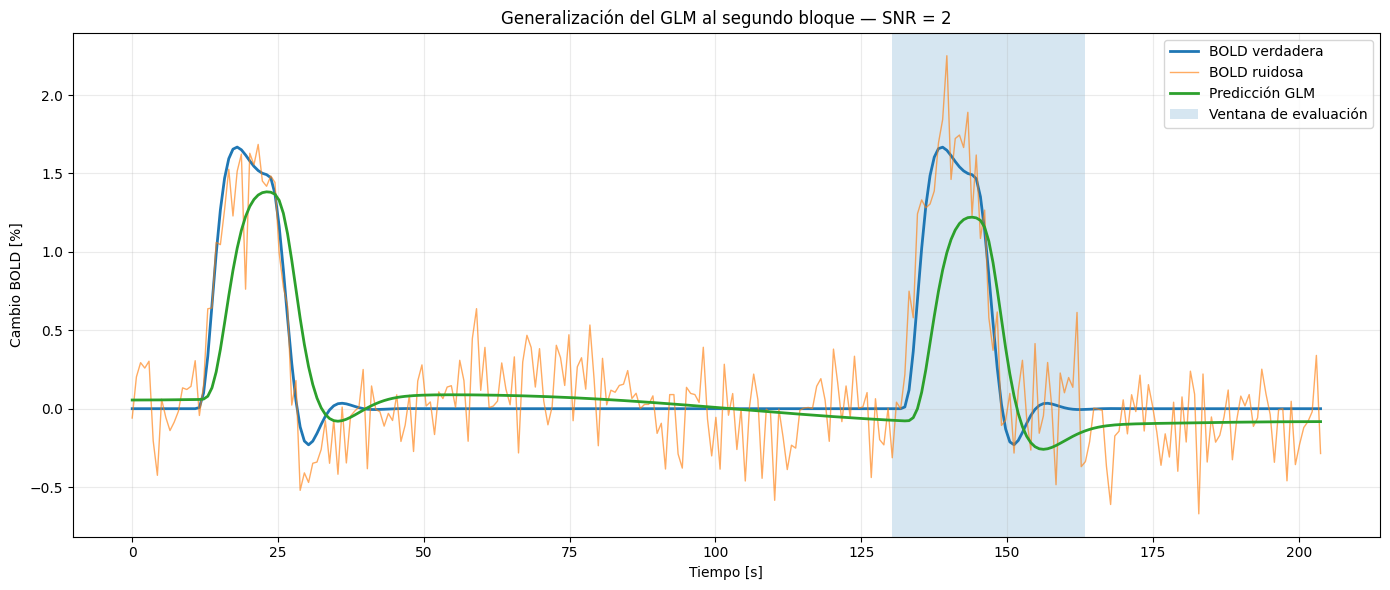

In [19]:
example_prediction = (
    glm_predictions.loc[
        (
            glm_predictions["scenario"]
            == "motor_lr_m1_left"
        )
        & (
            glm_predictions["snr_name"]
            == "snr_2"
        )
        & (
            glm_predictions["replicate"]
            == 1
        )
    ]
    .copy()
)

test_mask_example = (
    example_prediction[
        "test_mask"
    ].to_numpy(dtype=bool)
)

test_times = (
    example_prediction.loc[
        test_mask_example,
        "time_s",
    ]
)

plt.figure(figsize=(14, 6))

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction[
        "clean_fraction"
    ],
    label="BOLD verdadera",
    linewidth=2.0,
)

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction[
        "noisy_fraction"
    ],
    label="BOLD ruidosa",
    linewidth=1.0,
    alpha=0.65,
)

plt.plot(
    example_prediction["time_s"],
    100.0
    * example_prediction[
        "predicted_fraction"
    ],
    label="Predicción GLM",
    linewidth=2.0,
)

plt.axvspan(
    float(test_times.min()),
    float(test_times.max()),
    alpha=0.18,
    label="Ventana de evaluación",
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "Generalización del GLM al segundo bloque — SNR = 2"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

example_figure_path = (
    FIGURES_DIR
    / "glm_synthetic_prediction_snr2.png"
)

plt.savefig(
    example_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

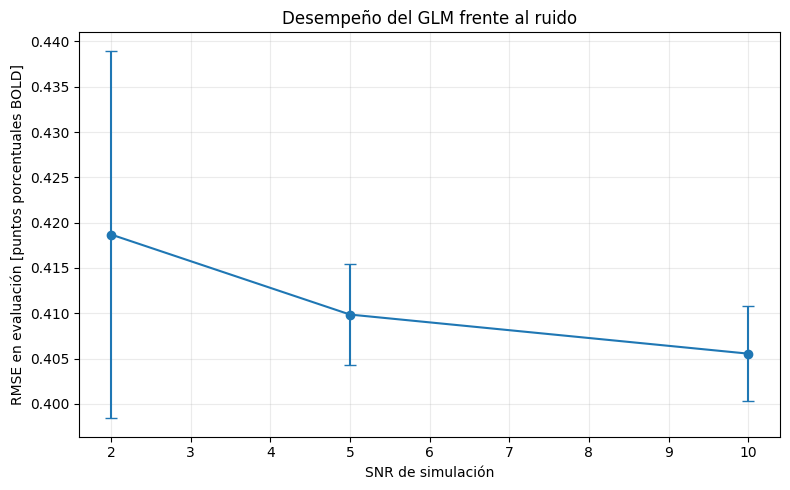

In [20]:
plot_summary = (
    glm_grouped_summary
    .sort_values("target_snr")
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    plot_summary["target_snr"],
    plot_summary["test_rmse_mean"],
    yerr=plot_summary["test_rmse_std"],
    marker="o",
    capsize=4,
)

plt.xlabel("SNR de simulación")
plt.ylabel("RMSE en evaluación [puntos porcentuales BOLD]")
plt.title("Desempeño del GLM frente al ruido")
plt.grid(alpha=0.25)
plt.tight_layout()

rmse_figure_path = (
    FIGURES_DIR
    / "glm_synthetic_rmse_vs_snr.png"
)

plt.savefig(
    rmse_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

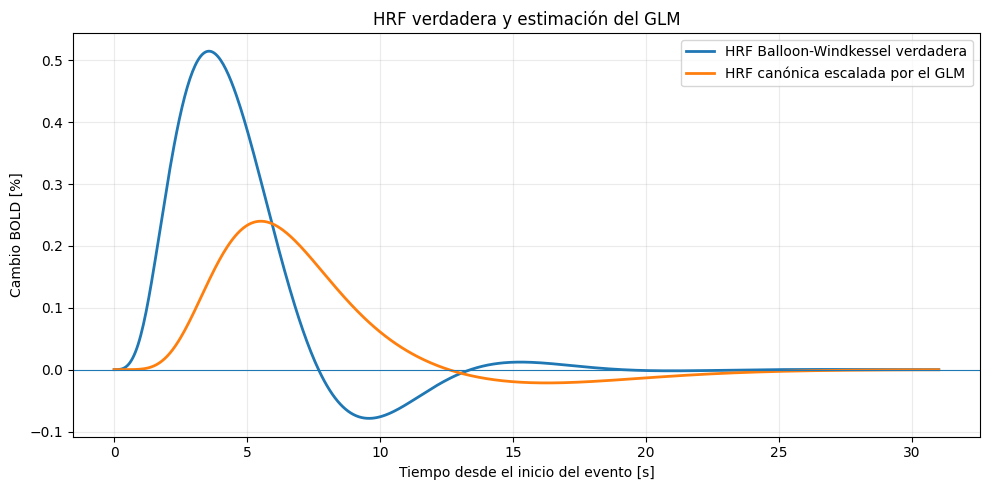

In [21]:
example_hrf = (
    glm_hrf_estimates.loc[
        (
            glm_hrf_estimates["scenario"]
            == "motor_lr_m1_left"
        )
        & (
            glm_hrf_estimates["snr_name"]
            == "snr_2"
        )
        & (
            glm_hrf_estimates["replicate"]
            == 1
        )
    ]
    .copy()
)

plt.figure(figsize=(10, 5))

plt.plot(
    example_hrf[
        "time_from_onset_s"
    ],
    100.0
    * example_hrf[
        "true_hrf_fraction"
    ],
    linewidth=2.0,
    label="HRF Balloon-Windkessel verdadera",
)

plt.plot(
    example_hrf[
        "time_from_onset_s"
    ],
    100.0
    * example_hrf[
        "estimated_hrf_fraction"
    ],
    linewidth=2.0,
    label="HRF canónica escalada por el GLM",
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.xlabel(
    "Tiempo desde el inicio del evento [s]"
)
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "HRF verdadera y estimación del GLM"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

hrf_figure_path = (
    FIGURES_DIR
    / "glm_synthetic_hrf_comparison_snr2.png"
)

plt.savefig(
    hrf_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()